In [1]:
import xarray as xr
import numpy as np
import rioxarray
from pathlib import Path
from matplotlib import pyplot as plt

In [2]:
work_dir = Path('/u/aurora-r0/govorcin/01_OPERA/DSWx_SWOT/notebooks/data/swot_sample')

In [3]:
ds1 = xr.open_dataset(list(work_dir.rglob('SWOT*.nc'))[0], chunks={})
ds2 = xr.open_dataset(list(work_dir.rglob('SWOT*.nc'))[1], chunks={})

In [4]:
ds1

<xarray.Dataset> Size: 457MB
Dimensions:                  (x: 1528, y: 1527)
Coordinates:
  * x                        (x) float64 12kB 3.168e+05 3.169e+05 ... 4.695e+05
  * y                        (y) float64 12kB 3.773e+06 3.773e+06 ... 3.926e+06
Data variables: (12/39)
    crs                      object 8B ...
    longitude                (y, x) float64 19MB dask.array<chunksize=(509, 510), meta=np.ndarray>
    latitude                 (y, x) float64 19MB dask.array<chunksize=(509, 510), meta=np.ndarray>
    wse                      (y, x) float32 9MB dask.array<chunksize=(764, 764), meta=np.ndarray>
    wse_qual                 (y, x) float32 9MB dask.array<chunksize=(1527, 1528), meta=np.ndarray>
    wse_qual_bitwise         (y, x) float64 19MB dask.array<chunksize=(764, 764), meta=np.ndarray>
    ...                       ...
    load_tide_fes            (y, x) float32 9MB dask.array<chunksize=(764, 764), meta=np.ndarray>
    load_tide_got            (y, x) float32 9MB dask.array<chunksize=(764, 764), meta=np.ndarray>
    pole_tide                (y, x) float32 9MB dask.array<chunksize=(764, 764), meta=np.ndarray>
    model_dry_tropo_cor      (y, x) float32 9MB dask.array<chunksize=(764, 764), meta=np.ndarray>
    model_wet_tropo_cor      (y, x) float32 9MB dask.array<chunksize=(764, 764), meta=np.ndarray>
    iono_cor_gim_ka          (y, x) float32 9MB dask.array<chunksize=(764, 764), meta=np.ndarray>
Attributes: (12/49)
    Conventions:                   CF-1.7
    title:                         Level 2 KaRIn High Rate Raster Data Product
    source:                        Ka-band radar interferometer
    history:                       2025-03-19T11:28:19Z : Creation
    platform:                      SWOT
    references:                    V1.3.1
    ...                            ...
    x_min:                         316800.0
    x_max:                         469500.0
    y_min:                         3773300.0
    y_max:                         3925900.0
    institution:                   CNES
    product_version:               01

In [5]:
comb_bounds = np.vstack([ds1.rio.bounds(), ds2.rio.bounds()])
x_min =  np.min(comb_bounds, axis=0)[0]
y_min =   np.min(comb_bounds, axis=0)[1]
x_max = np.max(comb_bounds, axis=0)[2]
y_max =  np.max(comb_bounds, axis=0)[3]

In [6]:
comb_bounds

array([[ 316750., 3773250.,  469550., 3925950.],
       [ 289350., 3648350.,  441850., 3800950.]])

In [7]:
x_min, x_max, y_min, y_max

(np.float64(289350.0),
 np.float64(469550.0),
 np.float64(3648350.0),
 np.float64(3925950.0))

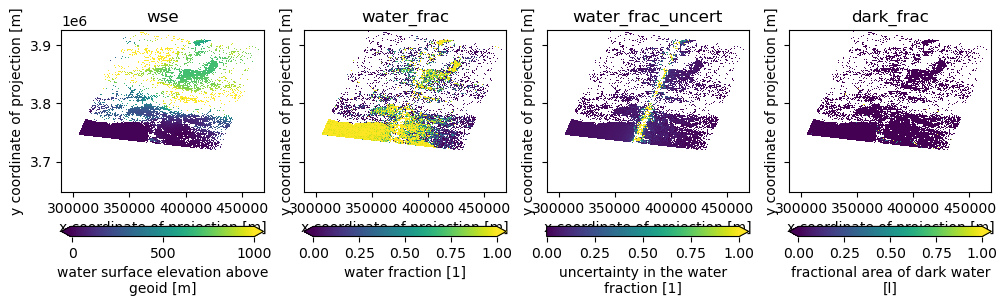

In [8]:
fig, ax = plt.subplots(1,4, figsize=(12,3), sharey=True)
ds1.wse.plot.imshow(ax=ax[0], vmin=-10, vmax=1000, cmap='viridis', add_colorbar=False)
ds2.wse.plot.imshow(ax=ax[0], vmin=-10, vmax=1000, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[0].set_title('wse')

ds1.water_frac.plot.imshow(ax=ax[1],  vmin=0, vmax=1, cmap='viridis', add_colorbar=False)
ds2.water_frac.plot.imshow(ax=ax[1], vmin=0, vmax=1, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[1].set_title('water_frac')

ds1.water_frac_uncert.plot.imshow(ax=ax[2],  vmin=0, vmax=1, cmap='viridis', add_colorbar=False)
ds2.water_frac_uncert.plot.imshow(ax=ax[2], vmin=0, vmax=1, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[2].set_title('water_frac_uncert')

# Dark water (the area that was not observed directly by SWOT ownung to a low radar backscatter that can occur over smooth surfaces, or significant attenuation during rain)

ds1.dark_frac.plot.imshow(ax=ax[3], vmin=0, vmax=1, cmap='viridis', add_colorbar=False)
ds2.dark_frac.plot.imshow(ax=ax[3], vmin=0, vmax=1, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[3].set_title('dark_frac')

for a in ax:
    a.set_xlim([x_min, x_max])
    a.set_ylim([y_min, y_max])


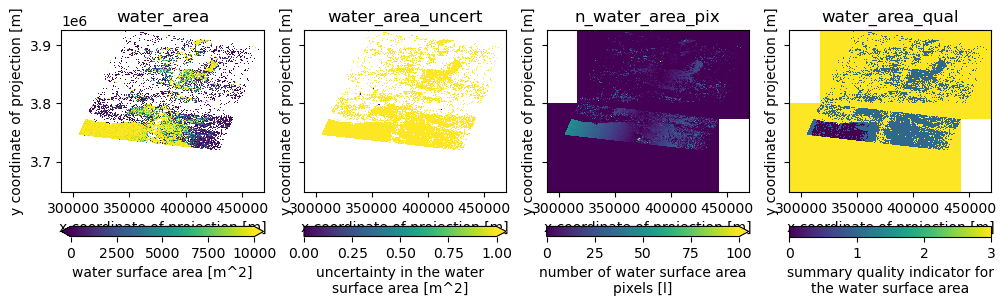

In [9]:
fig, ax = plt.subplots(1,4, figsize=(12,3), sharey=True)
ds1.water_area.plot.imshow(ax=ax[0], vmin=0, vmax=1e4, cmap='viridis', add_colorbar=False)
ds2.water_area.plot.imshow(ax=ax[0], vmin=0, vmax=1e4, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[0].set_title('water_area')

ds1.water_area_uncert.plot.imshow(ax=ax[1],  vmin=0, vmax=1, cmap='viridis', add_colorbar=False)
ds2.water_area_uncert.plot.imshow(ax=ax[1], vmin=0, vmax=1, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[1].set_title('water_area_uncert')

ds1.n_water_area_pix.plot.imshow(ax=ax[2], vmin=0, vmax=1e2, cmap='viridis', add_colorbar=False)
ds2.n_water_area_pix.plot.imshow(ax=ax[2], vmin=0, vmax=1e2, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[2].set_title('n_water_area_pix')

ds1.water_area_qual.plot.imshow(ax=ax[3], vmin=0, vmax=3, cmap='viridis', add_colorbar=False)
ds2.water_area_qual.plot.imshow(ax=ax[3], vmin=0, vmax=3, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[3].set_title('water_area_qual')

for a in ax:
    a.set_xlim([x_min, x_max])
    a.set_ylim([y_min, y_max])

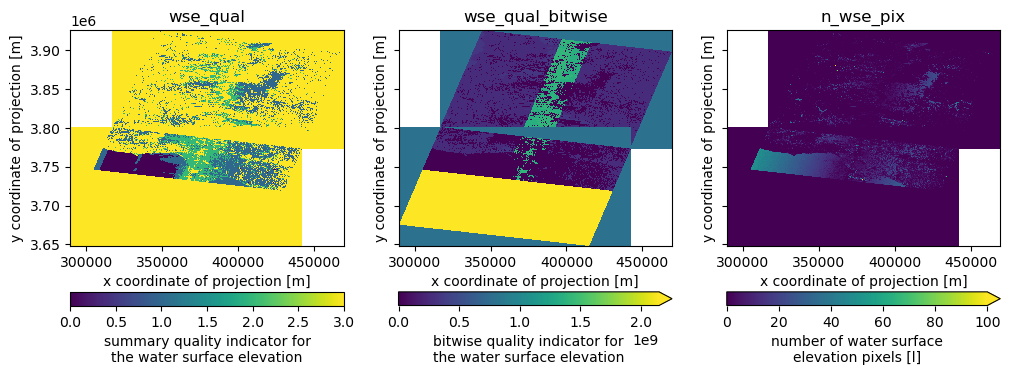

In [10]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
# wse_qual [0 good, 1 suspect, 2 degraded 3 bad meausurment]
ds1.wse_qual.plot.imshow(ax=ax[0], vmin=0, vmax=3, cmap='viridis', add_colorbar=False)
ds2.wse_qual.plot.imshow(ax=ax[0], vmin=0, vmax=3, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[0].set_title('wse_qual')

# classification_qual_suspect 2
# geolocation_qual_suspect 4
# large_uncert_suspect 32
#bright_land 128
# specular_ringing_prior_water_suspect 512
# few_pixels 4096
# far_range_suspect 8192
# near_range_suspect 16384
# classification_qual_degraded 16384
# geolocation_qual_degraded 262144
# dark_water_degraded 524288
# low_coherence_water_degraded 1048576
# specular_ringing_prior_land_degraded 2097152
# value_bad 4194304
# outside_data_window 16777216
# no_pixels 67108864
# outside_scene_bounds 268435456
# inner_swath missing_karin_data 536870912

# 2**1, 2**2, 2**5, 2**7, 2**9, 2**12, 2**13, 2**14, 2**18, 2**19, 2**20, 2**21, 2**22, 2**24, 2**26, 2**28, 2**29, 2**30, 2**31
# [1, 2,5, 7, 9, 13, 14, 18, 19, 20, 21, 22, 24, 26, 28,29,30, 31]
# 0 == good data
ds1.wse_qual_bitwise.plot.imshow(ax=ax[1],  vmin=0, vmax=2**31, cmap='viridis', add_colorbar=False)
ds2.wse_qual_bitwise.plot.imshow(ax=ax[1], vmin=0, vmax=2**31, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[1].set_title('wse_qual_bitwise')

ds1.n_wse_pix.plot.imshow(ax=ax[2], vmin=0, vmax=100, cmap='viridis', add_colorbar=False)
ds2.n_wse_pix.plot.imshow(ax=ax[2], vmin=0, vmax=100, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[2].set_title('n_wse_pix')

for a in ax:
    a.set_xlim([x_min, x_max])
    a.set_ylim([y_min, y_max])


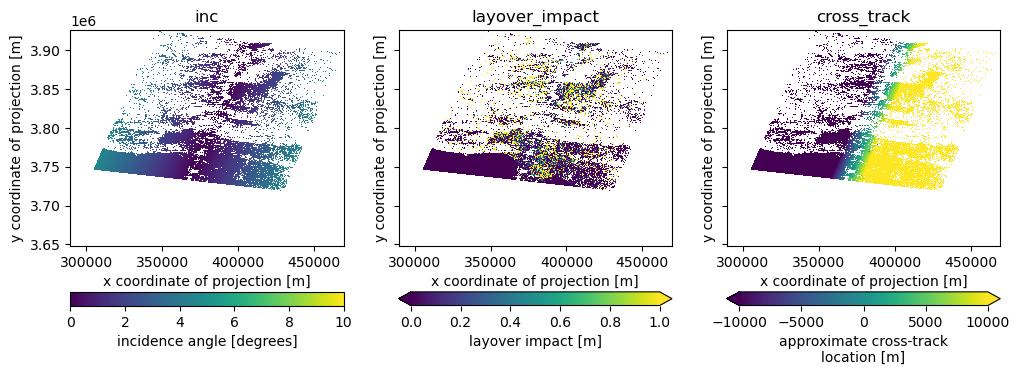

In [11]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
ds1.inc.plot.imshow(ax=ax[0], vmin=0, vmax=10, cmap='viridis', add_colorbar=False)
ds2.inc.plot.imshow(ax=ax[0], vmin=0, vmax=10, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[0].set_title('inc')

ds1.layover_impact.plot.imshow(ax=ax[1],  vmin=0, vmax=1, cmap='viridis', add_colorbar=False)
ds2.layover_impact.plot.imshow(ax=ax[1], vmin=0, vmax=1, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[1].set_title('layover_impact')

ds1.cross_track.plot.imshow(ax=ax[2], vmin=-1e4, vmax=1e4, cmap='viridis', add_colorbar=False)
ds2.cross_track.plot.imshow(ax=ax[2], vmin=-1e4, vmax=1e4, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[2].set_title('cross_track')

for a in ax:
    a.set_xlim([x_min, x_max])
    a.set_ylim([y_min, y_max])

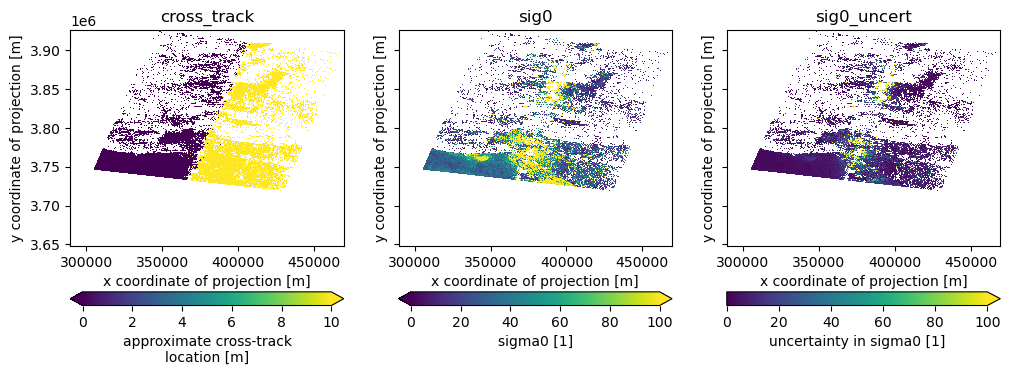

In [12]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
ds1.cross_track.plot.imshow(ax=ax[0], vmin=0, vmax=10, cmap='viridis', add_colorbar=False)
ds2.cross_track.plot.imshow(ax=ax[0], vmin=0, vmax=10, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[0].set_title('cross_track')

ds1.sig0.plot.imshow(ax=ax[1],  vmin=0, vmax=100, cmap='viridis', add_colorbar=False)
ds2.sig0.plot.imshow(ax=ax[1], vmin=0, vmax=100, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[1].set_title('sig0')

ds1.sig0_uncert.plot.imshow(ax=ax[2], vmin=0, vmax=100, cmap='viridis', add_colorbar=False)
ds2.sig0_uncert.plot.imshow(ax=ax[2], vmin=0, vmax=100, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[2].set_title('sig0_uncert')

for a in ax:
    a.set_xlim([x_min, x_max])
    a.set_ylim([y_min, y_max])

Text(0.5, 1.0, 'wse+geoid')

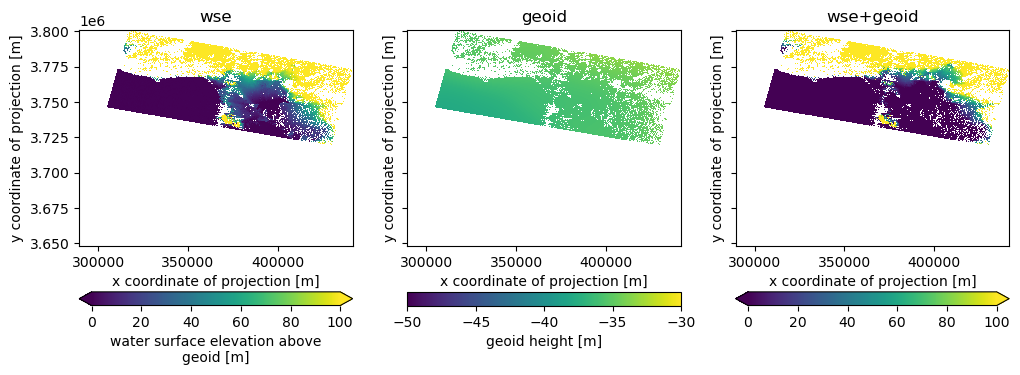

In [13]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
ds2.wse.plot.imshow(ax=ax[0], vmin=0, vmax=100, cmap='viridis', cbar_kwargs={'location':'bottom'})
ds2.geoid.plot.imshow(ax=ax[1], vmin=-50, vmax=-30, cmap='viridis', cbar_kwargs={'location':'bottom'})
(ds2.wse + ds2.geoid).plot.imshow(ax=ax[2], vmin=0, vmax=100, cmap='viridis', cbar_kwargs={'location':'bottom'})
ax[0].set_title('wse')
ax[1].set_title('geoid')
ax[2].set_title('wse+geoid')


# READ required layers and map it to MGRS tile regular 90m grid

DSWx-SAR layers
- water classification WTR [0, not water, 1 open water, 2 inundated vegetation]
- binary water BWTR [0 not water, 1 water]
- confidence CONF [0 not water, 1 open water high confidence, 2 open water moderate confidence, 6  low backscatterin not water, 7 low backscatterin not water (anxilliary)], same for wetland starting at 30-37
 - diagnostic DIAG [0 -100] fuzzy value for WTR classification coming from backscatter, ref water, slope angle and HAND value

Mask values
250 height above drainage mask, 251 layover/shadow mask, 255 fill value/no data